**Installing Dependencies**

In [ ]:
!pip install pandas numpy torch matplotlib seaborn scikit-learn transformers datasets evaluate accelerate openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.7 MB/s eta 0:00:00


**Importing Dependencies**

In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)

from datasets import Dataset
from evaluate import load

In [ ]:
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Device: cuda


**Initialize Phases (Setup)**

In [ ]:
dfA = pd.read_csv('/content/Combined .csv')

In [ ]:
dfB = pd.read_excel('/content/Notri-Fact_Real_Unreal_Urdu_NEWS.xlsx')

In [ ]:
dfA.head()

,Sr. No.,News Items,Label
0,1,ٹی ٹی پی نے پنجاب حکومت کے ہیلی کاپٹر کے عملے ...,FAKE
1,2,مارک زکربرگ سیاست میں آنے کا سوچ رہے ہیں۔,FAKE
2,3,فریدہ جلال نے اپنی موت کی افواہوں پر تنقید کی۔,FAKE
3,4,جعلی خبریں: پاپ اسٹار حدیقہ کیانی نے جعلی منشی...,FAKE
4,5,صنم ماروی نے میڈیا پر گردش کرنے والی زیادتی او...,FAKE


In [ ]:
dfA.shape

(10106, 3)

In [ ]:
dfA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10106 entries, 0 to 10105
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Sr. No.     10084 non-null  object
 1   News Items  10084 non-null  object
 2   Label       10084 non-null  object
dtypes: object(3)
memory usage: 237.0+ KB


In [ ]:
dfB.head()

,Index,Headline,News_Text,Category,Date,News_length,Label
0,1,گاڑیوں کی فروخت میں ان منی کا دھندہ روکنے کیلئ...,اسلام اباد 92 نیوز حکومت نے گاڑیوں کی فروخت می...,Business & Economics,"December 13, 2020",927,Real
1,2,صنعتکار سراج قاسم تیلی انتقال کرگئے,کراچی 92 نیوز صنعتکار سراج قاسم تیلی دبئی میں ...,Business & Economics,"December 8, 2020",837,Real
2,3,رواں ہفتے مہنگائی میں 023 فیصد کمی 13 اشیاء سس...,اسلام اباد 92 نیوز ادارہ شماریات کے مطابق رواں...,Business & Economics,"December 4, 2020",881,Real
3,4,ڈیزل کی قیمت میں 4روپے ضافہ نئی قیمت 10543 روپ...,وزارت خزانہ کی جانب سے جاری نوٹیفکیشن کے مطابق...,Business & Economics,"November 30, 2020",455,Real
4,5,ایئر سیال اپنے اپریشنز شروع کرنے کو تیار کراچی...,ایئرسیال پہلے ایئر بس اے تھری ٹوئنٹی طیارے کی ...,Business & Economics,"November 29, 2020",684,Real


In [ ]:
dfB.shape

(13388, 7)

In [ ]:
dfB.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13388 entries, 0 to 13387
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Index        13388 non-null  int64 
 1   Headline     13388 non-null  object
 2   News_Text    13388 non-null  object
 3   Category     13388 non-null  object
 4   Date         13388 non-null  object
 5   News_length  13388 non-null  int64 
 6   Label        13388 non-null  object
dtypes: int64(2), object(5)
memory usage: 732.3+ KB


In [ ]:
dfA['Label'] = dfA['Label'].astype(str).str.strip().str.upper()
dfA['Label'].value_counts()

,count
Label,
FAKE,5053
TRUE,5030
NAN,22
LABEL,1


In [ ]:
dfA = dfA[~dfA['Label'].isin(['NAN', 'LABEL'])]
dfA['Label'].value_counts()

,count
Label,
FAKE,5053
TRUE,5030


<Axes: xlabel='Label'>

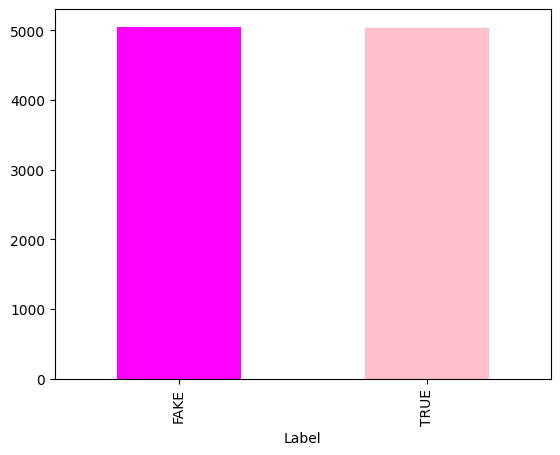

In [ ]:
dfA['Label'].value_counts().plot(kind = 'bar', color = ['magenta', 'pink'])

In [ ]:
dfA['Label'].value_counts()

,count
Label,
FAKE,5053
TRUE,5030


<Axes: xlabel='Label'>

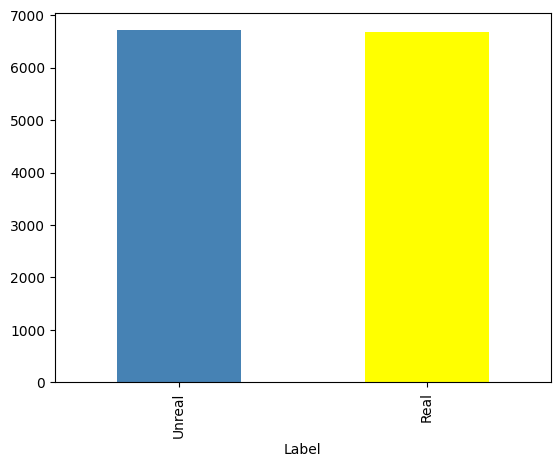

In [ ]:
dfB['Label'].value_counts().plot(kind = 'bar', color = ['steelblue', 'yellow'])

In [ ]:
dfB['Label'].value_counts()

,count
Label,
Unreal,6711
Real,6677


In [ ]:
overlap_rate = dfB.apply(
      lambda r: str(r["Headline"])[:30] in str(r["News_Text"]),axis=1).mean()
print(f"Headline-in-body overlap rate: {overlap_rate:.3f}")


Headline-in-body overlap rate: 0.235


### Standardizing and Combining Datasets

In [ ]:
dfA_processed = dfA[['News Items', 'Label']].copy()
dfA_processed.rename(columns={'News Items': 'News'}, inplace=True)
dfA_processed['Label'] = dfA_processed['Label'].map({'FAKE': 0, 'TRUE': 1}).astype(int)

dfB_processed = dfB[['News_Text', 'Label', 'News_length']].copy()
dfB_processed.rename(columns={'News_Text': 'News'}, inplace=True)
dfB_processed['Label'] = dfB_processed['Label'].map({'Unreal': 0, 'Real': 1}).astype(int)

df_combined = pd.concat([dfA_processed, dfB_processed], ignore_index=True)

df_shuffled = df_combined.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("df_shuffled initialized.")

df_shuffled initialized.


In [ ]:
df_shuffled = df_shuffled.drop_duplicates()

print(f"Number of duplicated rows after dropping: {df_shuffled.duplicated().sum()}")
display(df_shuffled.head())

Number of duplicated rows after dropping: 0


,News,Label,News_length
0,کراچی92نیوزماہی گیری اور مچھلیوں کی افزائش کے ...,0,704.0
1,کراچی 92 نیوز پاکستان موٹر ڈیلرز ایسوسی ایشن ک...,1,987.0
2,لندنسپورٹس ڈیسککھیل کی دنیا میں کبھی کبھی ایسے...,0,848.0
3,ٹوکیو 92 نیوز جاپان میں دنیا کا سب سے ننھا اسپ...,1,333.0
4,نئی دہلیسپورٹس ڈیسکبلائنڈ ٹی ٹونٹی ورلڈ کپ میں...,0,750.0


### Word Count Analysis

In [ ]:
df_shuffled['word_count'] = df_shuffled['News'].astype(str).apply(lambda x: len(x.split()))

print("DataFrame with 'word_count' column:")
display(df_shuffled.head())

DataFrame with 'word_count' column:


,News,Label,News_length,word_count
0,کراچی92نیوزماہی گیری اور مچھلیوں کی افزائش کے ...,0,704.0,142
1,کراچی 92 نیوز پاکستان موٹر ڈیلرز ایسوسی ایشن ک...,1,987.0,201
2,لندنسپورٹس ڈیسککھیل کی دنیا میں کبھی کبھی ایسے...,0,848.0,186
3,ٹوکیو 92 نیوز جاپان میں دنیا کا سب سے ننھا اسپ...,1,333.0,74
4,نئی دہلیسپورٹس ڈیسکبلائنڈ ٹی ٹونٹی ورلڈ کپ میں...,0,750.0,163


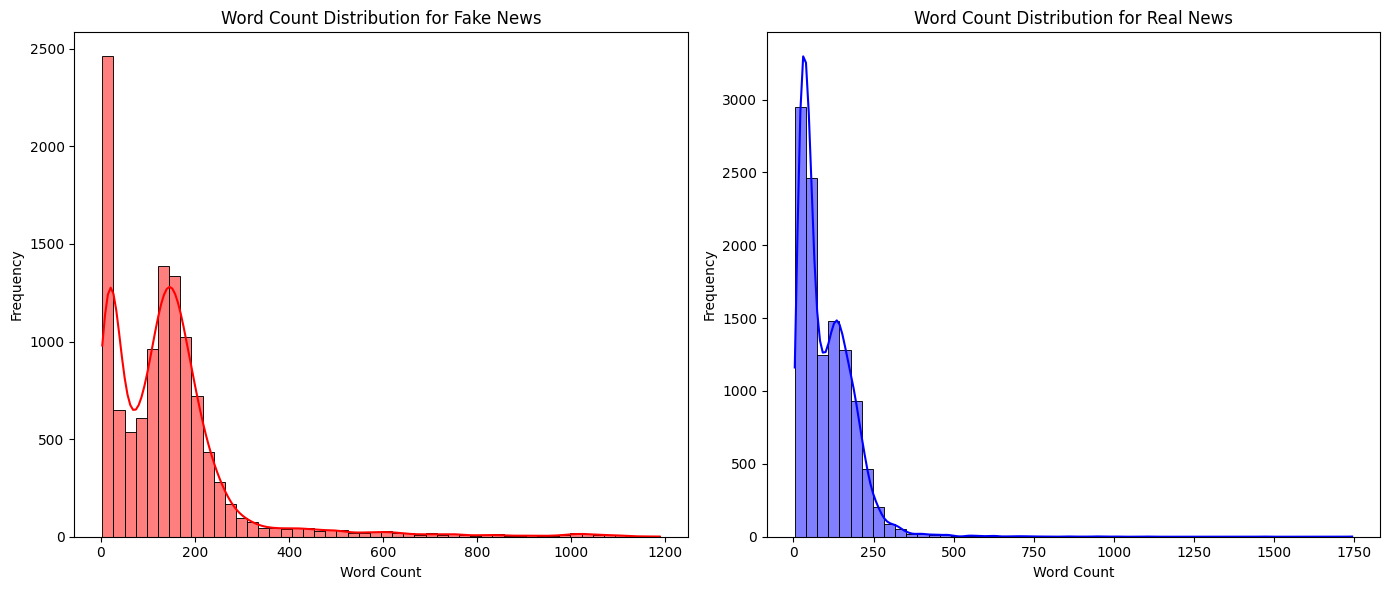

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df_shuffled[df_shuffled['Label'] == 0]['word_count'], bins=50, color='red', kde=True)
plt.title('Word Count Distribution for Fake News')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df_shuffled[df_shuffled['Label'] == 1]['word_count'], bins=50, color='blue', kde=True)
plt.title('Word Count Distribution for Real News')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
print("Summary statistics for word counts per label:")
display(df_shuffled.groupby('Label')['word_count'].describe())

Summary statistics for word counts per label:


,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
0,11348.0,142.000176,140.616331,3.0,39.0,130.0,181.0,1188.0
1,11275.0,101.789800,84.968908,4.0,37.0,79.0,151.0,1744.0


In [ ]:
df_a = df_shuffled[df_shuffled['News_length'].isna()][['News', 'Label']].copy()
df_b = df_shuffled[df_shuffled['News_length'].notna()][['News', 'Label']].copy()

df_a = df_a.rename(columns={'News': 'text', 'Label': 'label'})
df_b = df_b.rename(columns={'News': 'text', 'Label': 'label'})

df_a['source'] = 'ax_to_grind'
df_b['source'] = 'notri_fact'

df_a = df_a.reset_index(drop=True)
df_b = df_b.reset_index(drop=True)

print("df_a shape:", df_a.shape)
print("df_b shape:", df_b.shape)
print("df_a labels:", df_a['label'].value_counts().to_dict())
print("df_b labels:", df_b['label'].value_counts().to_dict())

df_a shape: (9235, 3)
df_b shape: (13388, 3)
df_a labels: {0: 4637, 1: 4598}
df_b labels: {0: 6711, 1: 6677}


In [ ]:
overlap = set(df_a['text'].str[:100]) & set(df_b['text'].str[:100])
print(f"Overlapping articles: {len(overlap)}")
assert len(overlap) == 0, "Datasets overlap - cross-domain experiments are contaminated!"

Overlapping articles: 0


**Transformers Setup**

In [ ]:
df_a['text'] = df_a['text'].astype(str).str.strip()
df_b['text'] = df_b['text'].astype(str).str.strip()

df_a = df_a[df_a['text'].str.len() > 0].reset_index(drop=True)
df_b = df_b[df_b['text'].str.len() > 0].reset_index(drop=True)

print("df_a:", df_a.shape)
print("df_b:", df_b.shape)

df_a: (9235, 3)
df_b: (13388, 3)


In [ ]:
modelName = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(modelName)
print("Tokenizer initialized.", modelName)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer initialized. xlm-roberta-base


In [ ]:
sample_texts = df_a['text'].sample(500, random_state=42).tolist()
lengths = [len(tokenizer(t)['input_ids']) for t in sample_texts]

print(f"Mean:     {np.mean(lengths):.0f}")
print(f"Median:   {np.median(lengths):.0f}")
print(f"90th pct: {np.percentile(lengths, 90):.0f}")
print(f"95th pct: {np.percentile(lengths, 95):.0f}")
print(f"99th pct: {np.percentile(lengths, 99):.0f}")

MAX_LENGTH = 256
print(f"\nUsing MAX_LENGTH = {MAX_LENGTH}")

Token indices sequence length is longer than the specified maximum sequence length for this model (930 > 512). Running this sequence through the model will result in indexing errors


Mean:     96
Median:   39
90th pct: 193
95th pct: 545
99th pct: 859

Using MAX_LENGTH = 256


In [ ]:
train_a, test_a = train_test_split(
    df_a,
    test_size=0.2,
    random_state=SEED,
    stratify=df_a['label']
)

print("Train size:", len(train_a))
print("Test size: ", len(test_a))
print("Train label distribution:", train_a['label'].value_counts().to_dict())
print("Test label distribution: ", test_a['label'].value_counts().to_dict())

Train size: 7388
Test size:  1847
Train label distribution: {0: 3710, 1: 3678}
Test label distribution:  {0: 927, 1: 920}


In [ ]:
def tokenize_fn(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH
    )

In [ ]:
from datasets import Dataset

train_ds_a = Dataset.from_pandas(train_a[['text', 'label']].reset_index(drop=True))
test_ds_a  = Dataset.from_pandas(test_a[['text', 'label']].reset_index(drop=True))

train_ds_a = train_ds_a.map(tokenize_fn, batched=True)
test_ds_a  = test_ds_a.map(tokenize_fn, batched=True)

train_ds_a.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_ds_a.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

print("Tokenization done")
print("Train:", train_ds_a)
print("Test: ", test_ds_a)

Map:   0%|          | 0/7388 [00:00<?, ? examples/s]

Map:   0%|          | 0/1847 [00:00<?, ? examples/s]

Tokenization done
Train: Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 7388
})
Test:  Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 1847
})


In [ ]:
from evaluate import load as load_metric

accuracy_metric = load_metric("accuracy")
f1_metric       = load_metric("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy":  accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"],
        "f1":        f1_metric.compute(predictions=predictions, references=labels)["f1"],
    }

In [ ]:
from transformers import TrainingArguments

training_args_1 = TrainingArguments(
    output_dir="./exp1_ax_to_grind",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    seed=SEED,
    logging_steps=50,
)

In [ ]:
from transformers import AutoModelForSequenceClassification, Trainer, DataCollatorWithPadding

model_1 = AutoModelForSequenceClassification.from_pretrained(
    modelName,
    num_labels=2
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer_1 = Trainer(
    model=model_1,
    args=training_args_1,
    train_dataset=train_ds_a,
    eval_dataset=test_ds_a,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
trainer_1.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.258972,0.312345,0.900920,0.896200
2,0.229821,0.246059,0.928533,0.928726
3,0.167158,0.270675,0.924201,0.925847


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1386, training_loss=0.271371711040128, metrics={'train_runtime': 1586.9017, 'train_samples_per_second': 13.967, 'train_steps_per_second': 0.873, 'total_flos': 2915796715499520.0, 'train_loss': 0.271371711040128, 'epoch': 3.0})

In [ ]:
results_1 = trainer_1.evaluate(test_ds_a)
print("Experiment 1: In-domain Ax-to-Grind")
print(results_1)

Experiment 1: In-domain Ax-to-Grind
{'eval_loss': 0.24615418910980225, 'eval_accuracy': 0.9285327558202491, 'eval_f1': 0.9287257019438445, 'eval_runtime': 25.4699, 'eval_samples_per_second': 72.517, 'eval_steps_per_second': 4.554, 'epoch': 3.0}


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

trainer_1.save_model('/content/drive/MyDrive/UrduFakeNews/exp1_model')
tokenizer.save_pretrained('/content/drive/MyDrive/UrduFakeNews/exp1_model')

df_a.to_csv('/content/drive/MyDrive/UrduFakeNews/df_a.csv', index=False)
df_b.to_csv('/content/drive/MyDrive/UrduFakeNews/df_b.csv', index=False)

Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]